In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#mesmo tratamento do notebook supervisionado
df_train = pd.read_csv('datasets/train.csv')
df_test = pd.read_csv('datasets/test.csv')

df_train['origem'] = 'treino'
df_test['origem'] = 'teste'
df_test['SalePrice'] = np.nan

df_full = pd.concat([df_train, df_test], ignore_index=True)
df_full.shape

(2919, 82)

In [3]:
cols_sem_recurso = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType',
]

for col in cols_sem_recurso:
    df_full[col] = df_full[col].fillna('Sem')

In [4]:
cols_sem_recurso_num = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'MasVnrArea',
                        'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
                        'BsmtFullBath', 'BsmtHalfBath']

for col in cols_sem_recurso_num:
    df_full[col] = df_full[col].fillna(0)

In [5]:
df_full['LotFrontage'] = df_full.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

In [6]:
cols_moda = ['MSZoning', 'Utilities', 'Exterior1st', 'Exterior2nd',
             'KitchenQual', 'Functional', 'SaleType', 'Electrical']

for col in cols_moda:
    df_full[col] = df_full[col].fillna(df_full[col].mode()[0])

In [7]:
outliers = df_full[(df_full['GrLivArea'] > 4000) & (df_full['SalePrice'] < 300000)].index
df_full = df_full.drop(index=outliers)

In [8]:
mapa_qualidade = {'Sem': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

cols_qualidade = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                   'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

for col in cols_qualidade:
    df_full[col] = df_full[col].map(mapa_qualidade)

In [9]:
df_full['area_total'] = df_full['TotalBsmtSF'] + df_full['1stFlrSF'] + df_full['2ndFlrSF']

In [10]:
cols_categoricas = df_full.select_dtypes(include='object').columns.drop('origem')
df_full = pd.get_dummies(df_full, columns=cols_categoricas, dtype='int64')
df_full.shape

C:\Users\Chyi Jaan Li\AppData\Local\Temp\ipykernel_18508\2840621533.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_categoricas = df_full.select_dtypes(include='object').columns.drop('origem')


(2917, 268)

In [ ]:
df_treino = df_full[df_full['origem'] == 'treino'].drop(columns=['origem', 'Id'])

precos_reais = df_treino['SalePrice']
x = df_treino.drop(columns=['SalePrice'])

x.shape

(1458, 265)

In [12]:
#kmeans e sensivel a escala, feature em m2 domina uma binaria do one-hot
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [13]:
#muita coluna do one-hot (~260), reduz dimensao antes do kmeans
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90, random_state=51)
x_pca = pca.fit_transform(x_scaled)

x_pca.shape

(1458, 138)

In [14]:
pca.n_components_

np.int64(138)

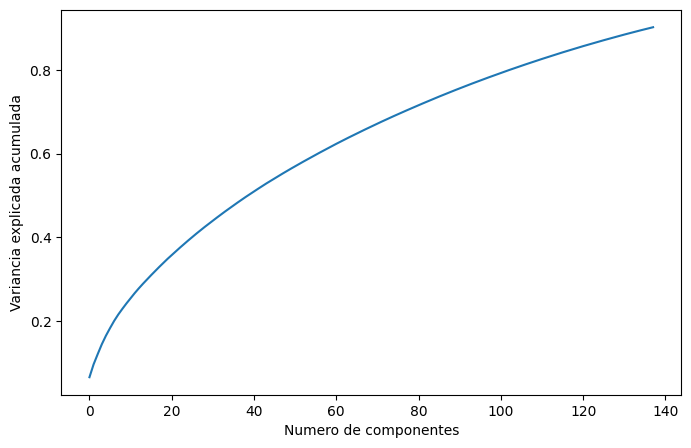

In [15]:
#componentes necessarios pra manter 90% da variancia
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Numero de componentes')
plt.ylabel('Variancia explicada acumulada')
plt.show()

In [16]:
#metodo do cotovelo pra escolher k
from sklearn.cluster import KMeans

inercias = []
valores_k = range(2, 11)

for k in valores_k:
    kmeans_teste = KMeans(n_clusters=k, random_state=51, n_init=10)
    kmeans_teste.fit(x_pca)
    inercias.append(kmeans_teste.inertia_)

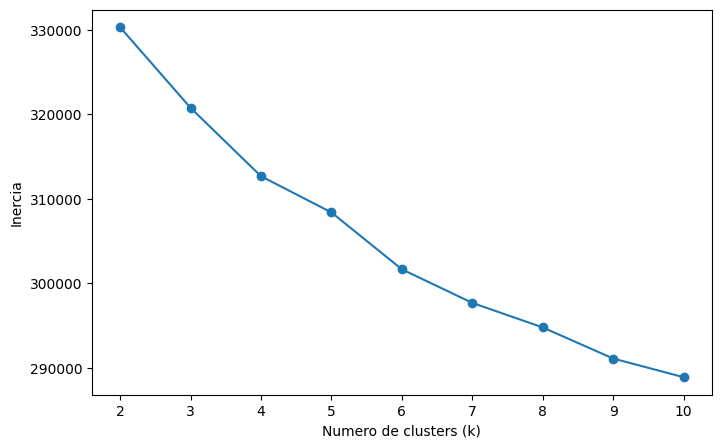

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(valores_k, inercias, marker='o')
plt.xlabel('Numero de clusters (k)')
plt.ylabel('Inercia')
plt.show()

In [18]:
#cotovelo em k=4
kmeans = KMeans(n_clusters=4, random_state=51, n_init=10)
clusters = kmeans.fit_predict(x_pca)

df_treino['cluster'] = clusters
df_treino['cluster'].value_counts()

cluster
1    579
2    530
0    312
3     37
Name: count, dtype: int64

In [ ]:
df_treino['SalePrice'] = precos_reais

df_treino.groupby('cluster')['SalePrice'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,312.0,124477.596154,43931.677692,34900.0,100000.0,119000.0,140000.0,475000.0
1,579.0,159335.744387,46189.265955,60000.0,130500.0,148500.0,175500.0,385000.0
2,530.0,243016.288679,85047.273626,130000.0,185000.0,221750.0,275375.0,755000.0
3,37.0,105652.891892,29278.694797,39300.0,90000.0,101800.0,118858.0,198500.0


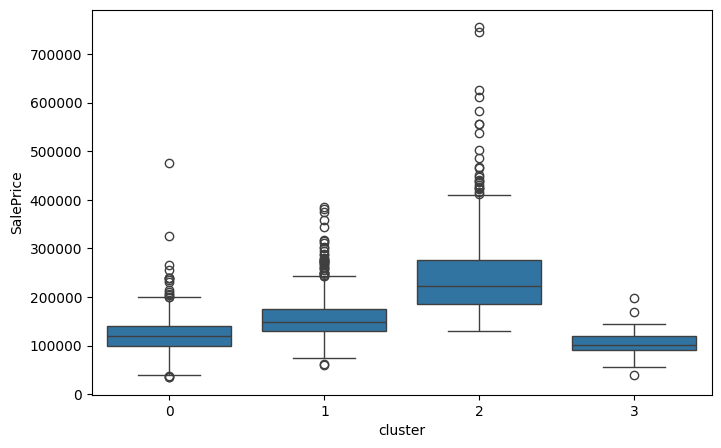

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_treino, x='cluster', y='SalePrice')
plt.show()

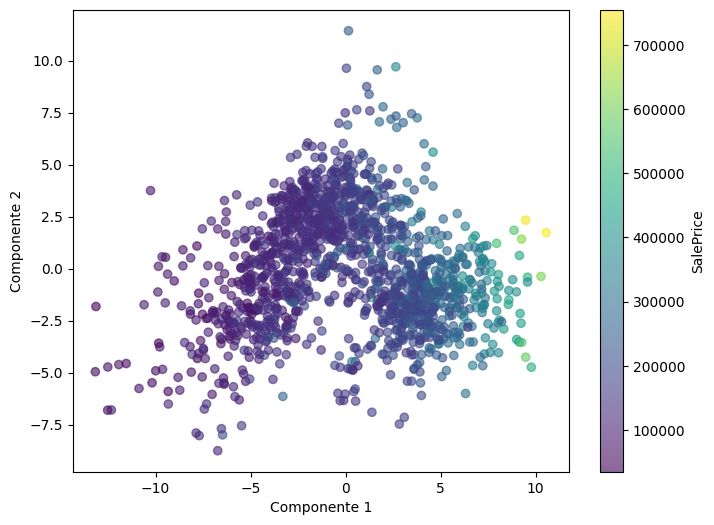

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=df_treino['SalePrice'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='SalePrice')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.show()

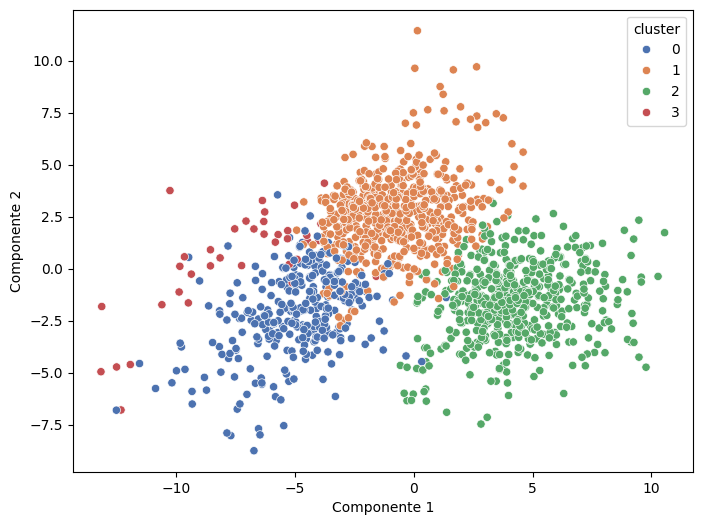

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=df_treino['cluster'], palette='deep')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.show()

In [ ]:
cols_perfil = ['OverallQual', 'area_total', 'GrLivArea', 'GarageCars', 'YearBuilt']

df_treino.groupby('cluster')[cols_perfil].mean()

,OverallQual,area_total,GrLivArea,GarageCars,YearBuilt
cluster,,,,,
0,5.198718,2164.740385,1369.333333,1.115385,1930.080128
1,5.583765,2440.248705,1379.407599,1.644214,1966.473230
2,7.303774,3004.471698,1752.160377,2.307547,2001.641509
3,4.297297,1287.891892,1289.324324,1.405405,1956.567568
